<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: Yilong Xu
<br>
Github Username: yilongxu-usc
<br>
USC ID: 9633003204

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
# Number of rows and columns
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 9568
Number of columns: 5


#### Answer for (b)i: The dataset contains 9,568 rows and 5 columns. Each row represents one hourly observation from the Combined Cycle Power Plant. The columns AT, V, AP, and RH are the predictor variables, representing Ambient Temperature, Exhaust Vacuum, Ambient Pressure, and Relative Humidity, respectively. PE is the response variable, representing the net hourly electrical energy output.

#### ii. pairwise scatterplots of all the varianbles

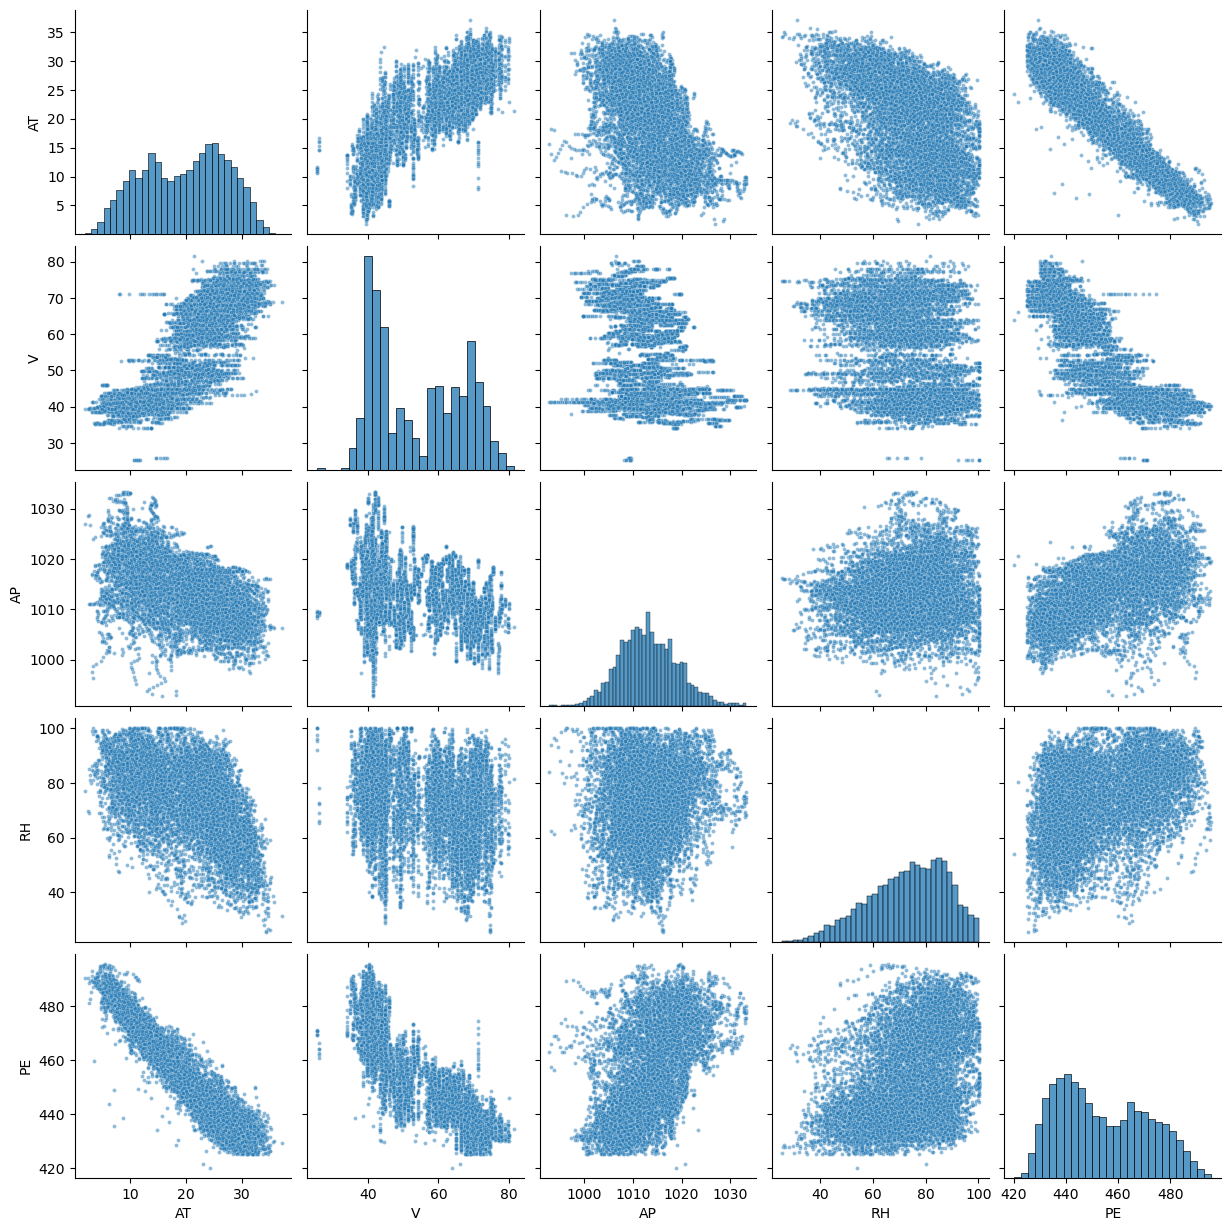

In [4]:
sns.pairplot(
    df,
    plot_kws={"s": 8, "alpha": 0.5}
)

plt.show()

#### Answer for (b)ii: From the pairwise scatterplots, AT and PE have a strong negative relationship. As ambient temperature increases, the electrical energy output generally decreases. V also has a strong negative relationship with PE, although the relationship appears to be somewhat nonlinear. AP has a positive relationship with PE, but the points are more widely scattered. RH also shows a positive relationship with PE, but this relationship is weaker than those of AT and V. There are also relationships among the predictor variables. For example, AT and V have a strong positive relationship, while AT and RH generally have a negative relationship. Overall, AT and V appear to have the strongest relationships with PE.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_stats.round(3)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


### (c) Simple Linear Regression

#### Step 1: Fit one simple linear regression for each predictor

In [6]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

for predictor in predictors:
    model = smf.ols(formula=f"PE ~ {predictor}", data=df).fit()
    simple_models[predictor] = model
    
    print(f"Simple Linear Regression: PE ~ {predictor}")
    print(model.summary())
    print()
regression_results = []

for predictor, model in simple_models.items():
    regression_results.append({
        "Predictor": predictor,
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

regression_table = pd.DataFrame(regression_results)

regression_table

Simple Linear Regression: PE ~ AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:48:39   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.034120,-2.171320,0.0,0.898948
1,V,517.801526,-1.168135,0.0,0.756518
2,AP,-1055.260989,1.489872,0.0,0.268769
3,RH,420.961766,0.455650,0.0,0.151939


#### Step 2: Make Regression Plots

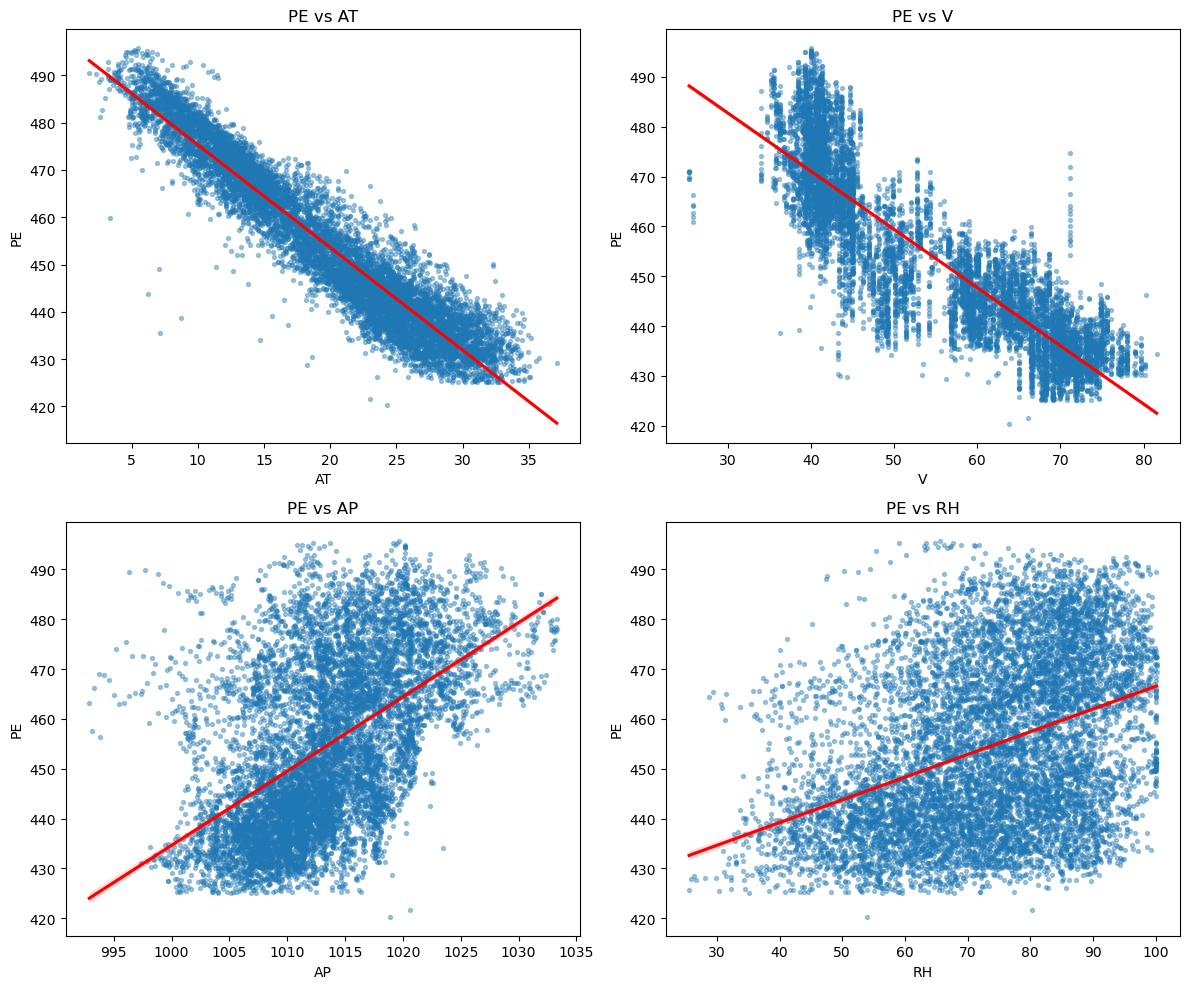

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, predictor in enumerate(predictors):
    sns.regplot(
        x=predictor,
        y="PE",
        data=df,
        ax=axes[i],
        scatter_kws={"s": 8, "alpha": 0.4},
        line_kws={"color": "red"}
    )
    
    axes[i].set_title(f"PE vs {predictor}")

plt.tight_layout()
plt.show()

#### Step 3: Check possible outliers

In [8]:
for predictor, model in simple_models.items():
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_external
    
    outliers = np.where(np.abs(studentized_residuals) > 3)[0]
    
    print(f"{predictor}: {len(outliers)} potential outliers")
    print("Indices:", outliers)
    print()

AT: 42 potential outliers
Indices: [ 202  437  464  611  786  887  930 1438 1568 1615 2670 2787 2882 2912
 2936 3117 3383 3522 3645 3895 4218 4325 4346 4601 4633 6156 6555 6628
 6656 6720 6790 7375 7398 7427 7647 7664 7837 8187 8192 8362 8717 9477]

V: 33 potential outliers
Indices: [ 182 1376 1438 1709 1773 1985 2217 2335 2385 2492 2993 3103 3117 3383
 3895 4070 5147 5283 5386 5418 5555 5852 6126 6289 6370 6573 6848 7664
 7752 8002 8432 8609 9089]

AP: 30 potential outliers
Indices: [ 618 1091 1290 1662 1735 1796 1907 1996 2047 2776 2972 3452 4002 4080
 4193 4598 4792 5238 6078 6229 6984 7031 7077 7091 7136 7182 7625 7941
 8827 9153]

RH: 2 potential outliers
Indices: [4719 7900]



#### Answer for (c): All four predictors have statistically significant associations with PE because their p-values are less than 0.05. AT has the strongest simple linear relationship with PE, with an R-squared of approximately 0.899 and a negative coefficient of about -2.17. This means that a one-unit increase in AT is associated with an average decrease of about 2.17 units in PE. V also has a strong negative relationship with PE, with an R-squared of approximately 0.757. AP and RH both have positive coefficients, but their R-squared values are much lower, indicating that they explain less of the variation in PE when used individually. The regression and residual analysis shows some potential outliers, especially for AT, V, and AP. However, I would not remove them automatically because there is no evidence that these observations are measurement errors. They should be treated as possible influential observations rather than deleted solely based on their residual values.

### (d) Multiple Regression

In [9]:
multiple_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:49:53   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

#### Answer for (d): The multiple linear regression model has an R-squared of approximately 0.929, which means that AT, V, AP, and RH together explain about 92.9% of the variation in PE. All four predictors have p-values less than 0.05. Therefore, we can reject the null hypothesis H0: βj = 0 for AT, V, AP, and RH. AT, V, and RH have negative coefficients, while AP has a positive coefficient. Holding the other predictors constant, increases in AT, V, and RH are associated with decreases in PE, while an increase in AP is associated with an increase in PE.

### (e) 1c Compare to 1d

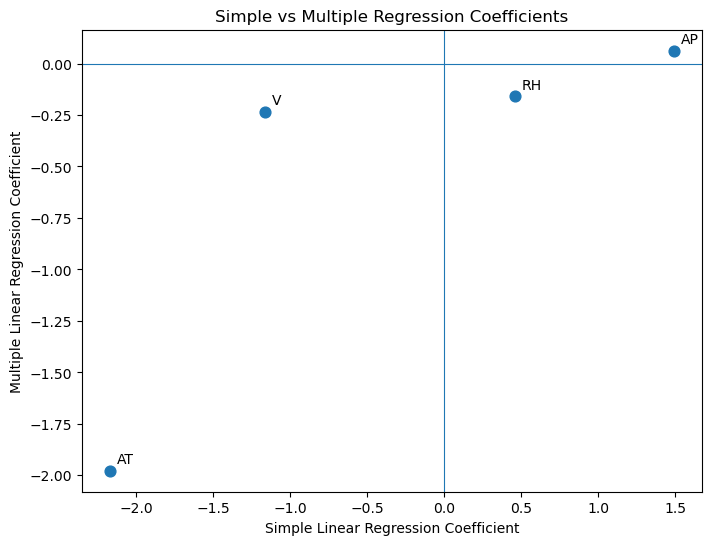

In [10]:
simple_coefficients = []
multiple_coefficients = []

for predictor in predictors:
    simple_coefficients.append(simple_models[predictor].params[predictor])
    multiple_coefficients.append(multiple_model.params[predictor])

coefficient_comparison = pd.DataFrame({
    "Predictor": predictors,
    "Simple Regression": simple_coefficients,
    "Multiple Regression": multiple_coefficients
})

coefficient_comparison

plt.figure(figsize=(8, 6))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=60
)

for _, row in coefficient_comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (row["Simple Regression"], row["Multiple Regression"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

#### Answer for (e): The coefficients from the simple and multiple linear regression models are noticeably different for some predictors. AT has similar negative coefficients in both models, although the magnitude is slightly smaller in the multiple regression model. The coefficient of V also remains negative, but its magnitude decreases substantially when the other predictors are included. AP changes from a relatively large positive coefficient in the simple regression model to a much smaller positive coefficient in the multiple regression model. RH shows the largest change in direction: its coefficient is positive in the simple regression model but becomes negative in the multiple regression model. These differences occur because the simple regression models consider each predictor separately, while the multiple regression model estimates the effect of each predictor while holding the other predictors constant. Since some of the predictors are correlated with each other, their estimated coefficients can change when they are included together in the same model.

### (f) Nonlinear Association

In [15]:
polynomial_models = {}
polynomial_results = []

for predictor in predictors:
    model = smf.ols(
        formula=f"PE ~ {predictor} + I({predictor}**2) + I({predictor}**3)",
        data=df
    ).fit()
    
    polynomial_models[predictor] = model
    
    polynomial_results.append({
        "Predictor": predictor,
        "Linear p-value": model.pvalues[predictor],
        "Quadratic p-value": model.pvalues[f"I({predictor} ** 2)"],
        "Cubic p-value": model.pvalues[f"I({predictor} ** 3)"],
        "R-squared": model.rsquared
    })

polynomial_results_df = pd.DataFrame(polynomial_results)

polynomial_results_df

C:\Users\yilon\AppData\Local\Temp\ipykernel_3112\778841849.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


#### Answer for (f): There is evidence of nonlinear association between each predictor and PE. For AT, both the quadratic and cubic terms are statistically significant. For V, the quadratic term is not statistically significant, but the cubic term is significant, which still provides evidence of a nonlinear relationship. For AP and RH, both the quadratic and cubic terms are statistically significant. Therefore, all four predictors show some evidence of nonlinear association with PE.

### (g) Interactions of Predictors

#### Step 1: Fit the interaction model

In [12]:
interaction_model = smf.ols(
    formula="PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:49:53   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

#### Step 2: Make table of the interaction p-values

In [13]:
interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

interaction_results = pd.DataFrame({
    "Interaction": interaction_terms,
    "P-value": [interaction_model.pvalues[term] for term in interaction_terms]
})

interaction_results["Significant at 0.05"] = np.where(
    interaction_results["P-value"] < 0.05,
    "Yes",
    "No"
)
interaction_results.round(3)

,Interaction,P-value,Significant at 0.05
0,AT:V,0.000,Yes
1,AT:AP,0.452,No
2,AT:RH,0.000,Yes
3,V:AP,0.000,Yes
4,V:RH,0.086,No
5,AP:RH,0.034,Yes


#### Answer for (g): Using a significance level of 0.05, four of the six pairwise interaction terms are statistically significant. The significant interactions are AT:V, AT:RH, V:AP, and AP:RH. Their p-values are less than 0.05. The interactions AT:AP and V:RH are not statistically significant because their p-values are greater than 0.05. Therefore, there is evidence that some interactions between the predictors are associated with PE.

### (h) Improvement

#### Step 1: Create the 70/30 train-test split

In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=1
)

print("Training set size:", train_df.shape)
print("Testing set size:", test_df.shape)

Training set size: (6697, 5)
Testing set size: (2871, 5)


#### Step 2: Linear model with all original predictors

In [17]:
linear_model_h = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=train_df
).fit()

print(linear_model_h.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 2.167e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:53:18   Log-Likelihood:                -19660.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.936e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    458.3988     11.562     39.649      0.0

In [18]:
# Train and MSE for the first regression model
linear_train_pred = linear_model_h.predict(train_df)
linear_test_pred = linear_model_h.predict(test_df)

linear_train_mse = mean_squared_error(
    train_df["PE"],
    linear_train_pred
)

linear_test_mse = mean_squared_error(
    test_df["PE"],
    linear_test_pred
)

print("Linear Model Train MSE:", linear_train_mse)
print("Linear Model Test MSE:", linear_test_mse)

Linear Model Train MSE: 20.766119761450938
Linear Model Test MSE: 20.77747810688448


#### Step 3: The full nonlinear + interaction model

In [19]:
full_formula = """
PE ~ AT + V + AP + RH
+ I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)
+ AT:V + AT:AP + AT:RH
+ V:AP + V:RH
+ AP:RH
"""

full_model_h = smf.ols(
    formula=full_formula,
    data=train_df
).fit()

print(full_model_h.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:55:36   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8171.8080   1416.708     -5.768      0.0

#### Step 4: Backward elimination using p-values

In [21]:
terms = [
    "AT",
    "V",
    "AP",
    "RH",
    "I(AT ** 2)",
    "I(V ** 2)",
    "I(AP ** 2)",
    "I(RH ** 2)",
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

higher_order_terms = [
    "I(AT ** 2)",
    "I(V ** 2)",
    "I(AP ** 2)",
    "I(RH ** 2)",
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

current_terms = terms.copy()

while True:
    formula = "PE ~ " + " + ".join(current_terms)
    model = smf.ols(formula=formula, data=train_df).fit()

    insignificant_terms = [
        term for term in higher_order_terms
        if term in current_terms and model.pvalues[term] > 0.05
    ]

    if len(insignificant_terms) == 0:
        break

    worst_term = max(
        insignificant_terms,
        key=lambda term: model.pvalues[term]
    )

    print(
        f"Removing {worst_term}, "
        f"p-value = {model.pvalues[worst_term]:.4f}"
    )

    current_terms.remove(worst_term)

reduced_model_h = model
# The final second model
print(reduced_model_h.summary())

Removing AT:AP, p-value = 0.7309
Removing V:RH, p-value = 0.4650
Removing I(V ** 2), p-value = 0.3875
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9142.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:57:25   Log-Likelihood:                -19193.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6685   BIC:                         3.849e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [22]:
# Train and MSE for the second regression model
reduced_train_pred = reduced_model_h.predict(train_df)
reduced_test_pred = reduced_model_h.predict(test_df)

reduced_train_mse = mean_squared_error(
    train_df["PE"],
    reduced_train_pred
)

reduced_test_mse = mean_squared_error(
    test_df["PE"],
    reduced_test_pred
)

print("Reduced Model Train MSE:", reduced_train_mse)
print("Reduced Model Test MSE:", reduced_test_mse)

Reduced Model Train MSE: 18.063666915213524
Reduced Model Test MSE: 18.232225767396013


#### Final table showing Train/MSE for both model

In [23]:
mse_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Interaction + Quadratic Regression"
    ],
    "Train MSE": [
        linear_train_mse,
        reduced_train_mse
    ],
    "Test MSE": [
        linear_test_mse,
        reduced_test_mse
    ]
})

mse_comparison.round(4)

,Model,Train MSE,Test MSE
0,Linear Regression,20.7661,20.7775
1,Interaction + Quadratic Regression,18.0637,18.2322


#### Answer for (h): The original multiple linear regression model has a training MSE of approximately 20.77 and a test MSE of approximately 20.78. After including pairwise interaction terms and quadratic nonlinearities, insignificant higher-order terms were removed one at a time using a significance level of 0.05. The final reduced model removed AT:AP, V:RH, and V², while retaining the significant interaction and nonlinear terms. The reduced model has a training MSE of approximately 18.06 and a test MSE of approximately 18.23. Since both the training and testing MSEs are lower than those of the original linear regression model, including selected interaction and nonlinear terms improves the predictive performance of the model.

### (i) KNN

In [25]:
features = ["AT", "V", "AP", "RH"]

X_train = train_df[features]
y_train = train_df["PE"]

X_test = test_df[features]
y_test = test_df["PE"]

#### Step 1: KNN using raw features

In [27]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    raw_train_mse.append(mean_squared_error(y_train, train_pred))
    raw_test_mse.append(mean_squared_error(y_test, test_pred))

# Find the best k:
best_raw_k = k_values[np.argmin(raw_test_mse)]
best_raw_test_mse = min(raw_test_mse)

print("Best k for raw features:", best_raw_k)
print("Best test MSE for raw features:", best_raw_test_mse)

Best k for raw features: 5
Best test MSE for raw features: 15.704821203761764


#### Step 2: KNN using normalized features

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    normalized_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )
    
    normalized_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )
# Find the best k:
best_normalized_k = k_values[np.argmin(normalized_test_mse)]
best_normalized_test_mse = min(normalized_test_mse)

print("Best k for normalized features:", best_normalized_k)
print("Best test MSE for normalized features:", best_normalized_test_mse)

Best k for normalized features: 4
Best test MSE for normalized features: 14.070606067136888


#### Step 3: Plot the Plot train and test errors against (1/k)

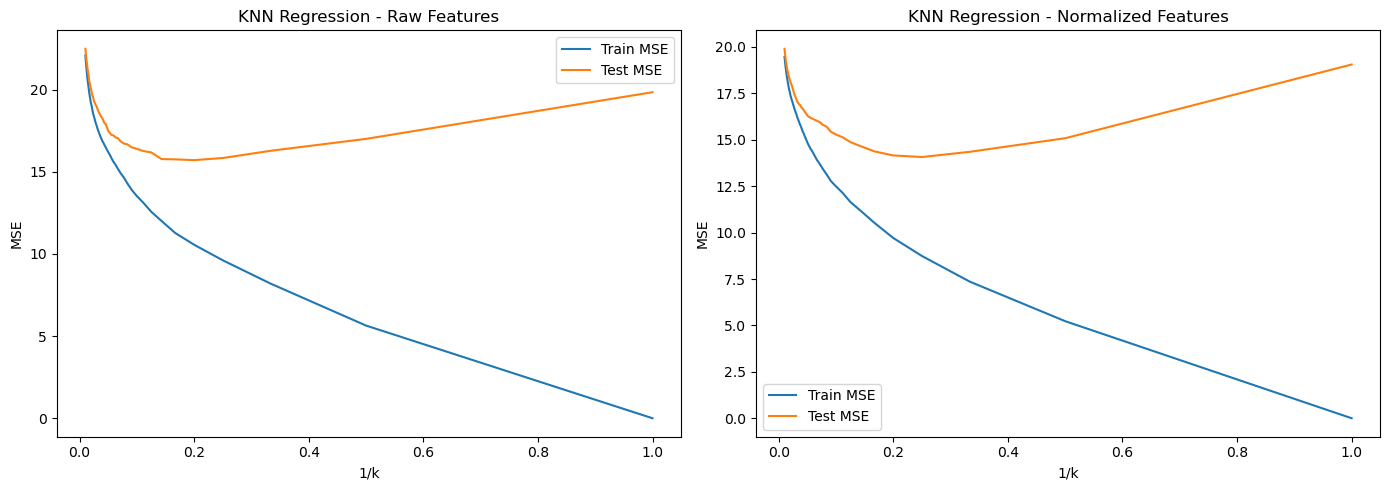

In [29]:
inverse_k = 1 / np.array(list(k_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw features
axes[0].plot(inverse_k, raw_train_mse, label="Train MSE")
axes[0].plot(inverse_k, raw_test_mse, label="Test MSE")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].set_title("KNN Regression - Raw Features")
axes[0].legend()

# Normalized features
axes[1].plot(inverse_k, normalized_train_mse, label="Train MSE")
axes[1].plot(inverse_k, normalized_test_mse, label="Test MSE")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].set_title("KNN Regression - Normalized Features")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Step 4: Summary table

In [30]:
knn_results = pd.DataFrame({
    "Features": ["Raw", "Normalized"],
    "Best k": [
        best_raw_k,
        best_normalized_k
    ],
    "Train MSE": [
        raw_train_mse[best_raw_k - 1],
        normalized_train_mse[best_normalized_k - 1]
    ],
    "Test MSE": [
        best_raw_test_mse,
        best_normalized_test_mse
    ]
})

knn_results.round(4)

,Features,Best k,Train MSE,Test MSE
0,Raw,5,10.5530,15.7048
1,Normalized,4,8.7385,14.0706


#### Answer for (i): For the raw features, the best value of k is 5, with a test MSE of approximately 15.70. For the normalized features, the best value of k is 4, with a test MSE of approximately 14.07. The normalized KNN model performs better because it has a lower test MSE. Feature scaling is important for KNN because the algorithm is based on distances between observations, and the predictors have different numerical scales.

### (j ) Compare KNN and Linear

In [33]:
comparison_results = pd.DataFrame({
    "Model": [
        "Reduced Interaction + Quadratic Regression",
        "KNN - Raw Features",
        "KNN - Normalized Features"
    ],
    "Test MSE": [
        reduced_test_mse,
        best_raw_test_mse,
        best_normalized_test_mse
    ]
})

comparison_results.round(4)

,Model,Test MSE
0,Reduced Interaction + Quadratic Regression,18.2322
1,KNN - Raw Features,15.7048
2,KNN - Normalized Features,14.0706


#### Answer for (j): The reduced interaction and quadratic regression model from part (h) has a test MSE of approximately 18.23. For KNN regression, the raw-feature model achieves a lower test MSE of approximately 15.70 with k = 5. After normalizing the predictors, the KNN model performs even better, with a test MSE of approximately 14.07 at k = 4. Therefore, the normalized KNN regression model has the lowest test error among these models. This suggests that KNN is able to capture relationships in the data that are not fully represented by the regression model. Normalization also improves KNN performance because KNN relies on distances between observations, and the predictors have different numerical scales. However, the regression model is easier to interpret because its coefficients describe the relationships between the predictors and PE, while KNN is mainly useful for prediction and does not provide coefficients with the same interpretation.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

#### A flexible method would generally perform better. Since the sample size is very large and there are only a few predictors, there is enough data for a flexible model to learn more complicated patterns without having a high risk of overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

#### A flexible method would generally perform worse. When the number of predictors is very large but the number of observations is small, a flexible model can easily fit the training data too closely. This can lead to overfitting and poor performance on new data.

### (c) The relationship between the predictors and response is highly non-linear.

#### A flexible method would generally perform better. If the relationship between the predictors and the response is highly nonlinear, a flexible method has a better chance of capturing this complicated relationship. An inflexible method may be too simple to represent the true pattern.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

#### A flexible method would generally perform worse. When the variance of the error terms is very high, there is a large amount of noise in the data. A flexible method may try to fit some of this noise instead of only learning the true relationship, which can increase variance and hurt its performance on new data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

#### (a)

The Euclidean distance from each observation to the test point $X=(0,0,0)$ is calculated by

$$
d=\sqrt{(X_1-0)^2+(X_2-0)^2+(X_3-0)^2}
$$

Observation 1: $\sqrt{0^2+3^2+0^2}=3$

Observation 2: $\sqrt{2^2+0^2+0^2}=2$

Observation 3: $\sqrt{0^2+1^2+3^2}=\sqrt{10}\approx3.162$

Observation 4: $\sqrt{0^2+1^2+2^2}=\sqrt{5}\approx2.236$

Observation 5: $\sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx1.414$

Observation 6: $\sqrt{1^2+1^2+1^2}=\sqrt{3}\approx1.732$

Therefore, the distances are approximately 3.000, 2.000, 3.162, 2.236, 1.414, and 1.732 for observations 1 through 6, respectively. From closest to farthest, the observations are 5, 6, 2, 4, 1, and 3.

### (b) What is our prediction with K = 1? Why?

#### (b)

When $K=1$, we only use the single closest training observation to classify the test point.

From part (a), Observation 5 is the closest point to $X=(0,0,0)$, with a distance of approximately $1.414$.

Observation 5 belongs to the Green class.

Therefore, the predicted class for $K=1$ is **Green**.

### (c) What is our prediction with K = 3? Why?

#### (c)

When $K=3$, we use the three closest training observations to classify the test point.

From part (a), the three nearest observations are Observation 5, Observation 6, and Observation 2.

Observation 5 is Green, while Observations 6 and 2 are Red. Since two of the three nearest neighbors are Red, the majority class is Red.

Therefore, the predicted class for $K=3$ is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

#### (d)

If the Bayes decision boundary is highly nonlinear, I would expect a relatively small value of $K$ to perform better.

A smaller $K$ makes the KNN classifier more flexible because the prediction depends only on nearby observations. This allows the decision boundary to change more easily in different parts of the feature space.

A larger $K$ uses more neighbors and produces a smoother, less flexible decision boundary, which may not capture a highly nonlinear pattern as well.